# Portfolio Comparison
Compare N portfolios across risk-adjusted performance, drawdown, KRD, and attribution.
Edit **Cell 2** to define your portfolios and benchmark.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path().resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools import (
    Portfolio, FI_ETF, Ticker,
    Panel, Chart, NotebookWorkbook, load_fred,
)
from tools.palette import Palette, NAVY, GOLD, COPPER, CHARCOAL, SILVER

## Configuration — edit this cell

In [2]:
START = "2018-01-01"   # history window for all portfolios
RF_FRED = "DGS3MO"     # FRED series for the risk-free rate

# ── Define portfolios ──────────────────────────────────────────────────────
# Keys: ticker symbols (str) or FI_ETF / Ticker objects
# Values: weights — automatically normalised to 1
# ──────────────────────────────────────────────────────────────────────────
PORTFOLIOS = [
    Portfolio(
        {"AGG": 0.60, "TLT": 0.20, "IEF": 0.20},
        name="Core Bond", start=START,
    ),
    Portfolio(
        {"TLT": 0.50, "VTIP": 0.50},
        name="Barbell", start=START,
    ),
    Portfolio(
        {"IEF": 0.40, "LQD": 0.40, "TIP": 0.20},
        name="Diversified", start=START,
    ),
]

BENCHMARK = Portfolio({"AGG": 1.0}, name="AGG", start=START)

# KRD tenors — set to [] to skip the KRD section
KRD_TENORS = ["DGS2", "DGS5", "DGS10", "DGS30"]

# Output path
OUTPUT = ROOT / "output" / "portfolio_comparison.xlsx"

In [3]:
# ── Risk-free rate ─────────────────────────────────────────────────────────
rf_series = load_fred(RF_FRED).dropna()
RF = float(rf_series.iloc[-1]) / 100
print(f"Risk-free rate ({RF_FRED}): {RF:.2%}")
print(f"Analysis window: {START} – today")
print(f"Portfolios: {[p.name for p in PORTFOLIOS]}")
print(f"Benchmark:  {BENCHMARK.name}")

Risk-free rate (DGS3MO): 3.69%
Analysis window: 2018-01-01 – today
Portfolios: ['Core Bond', 'Barbell', 'Diversified']
Benchmark:  AGG


## Helper functions

In [4]:
def information_ratio(port: Portfolio, bmark: Portfolio) -> float:
    """Annualised active return / tracking error."""
    aligned = pd.concat([port.returns, bmark.returns], axis=1).dropna()
    active = aligned.iloc[:, 0] - aligned.iloc[:, 1]
    te = active.std() * np.sqrt(252)
    return (active.mean() * 252) / te if te > 0 else np.nan


def tracking_error(port: Portfolio, bmark: Portfolio) -> float:
    """Annualised tracking error vs benchmark."""
    aligned = pd.concat([port.returns, bmark.returns], axis=1).dropna()
    return (aligned.iloc[:, 0] - aligned.iloc[:, 1]).std() * np.sqrt(252)


def active_return(port: Portfolio, bmark: Portfolio) -> float:
    """Annualised active (excess) return vs benchmark."""
    aligned = pd.concat([port.returns, bmark.returns], axis=1).dropna()
    return (aligned.iloc[:, 0] - aligned.iloc[:, 1]).mean() * 252


def sortino_ratio(port: Portfolio, rf: float = 0.0, periods: int = 252) -> float:
    """Annualised Sortino ratio (uses downside deviation only)."""
    r = port.returns
    ann_ret = r.mean() * periods
    downside = r[r < rf / periods].std() * np.sqrt(periods)
    return (ann_ret - rf) / downside if downside > 0 else np.nan


def portfolio_beta(port: Portfolio, bmark: Portfolio) -> float:
    """Portfolio beta vs benchmark."""
    aligned = pd.concat([port.returns, bmark.returns], axis=1).dropna()
    cov = np.cov(aligned.values.T)
    return cov[0, 1] / cov[1, 1] if cov[1, 1] > 0 else np.nan


def portfolio_alpha(port: Portfolio, bmark: Portfolio, rf: float = 0.0) -> float:
    """Jensen alpha (annualised)."""
    beta = portfolio_beta(port, bmark)
    ann_port = port.returns.mean() * 252
    ann_bmark = bmark.returns.mean() * 252
    return ann_port - (rf + beta * (ann_bmark - rf))


def max_drawdown_duration(port: Portfolio) -> int:
    """Longest drawdown duration in trading days."""
    cum = (1 + port.returns).cumprod()
    rolling_max = cum.cummax()
    dd = cum < rolling_max
    durations, current = [], 0
    for v in dd:
        if v:
            current += 1
        else:
            if current > 0:
                durations.append(current)
            current = 0
    if current > 0:
        durations.append(current)
    return max(durations) if durations else 0


def win_rate(port: Portfolio) -> float:
    """Fraction of positive-return days."""
    r = port.returns.dropna()
    return (r > 0).mean()


print("Helpers loaded.")

Helpers loaded.


## Full Performance Table

In [5]:
all_ports = PORTFOLIOS + ([BENCHMARK] if BENCHMARK not in PORTFOLIOS else [])

rows = {}
for p in all_ports:
    r = p.returns.dropna()
    ann_ret  = r.mean() * 252
    ann_vol  = r.std()  * np.sqrt(252)
    cum      = (1 + r).cumprod()
    max_dd   = (cum / cum.cummax() - 1).min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    rows[p.name] = {
        "Ann Return": f"{ann_ret:.2%}",
        "Ann Vol":    f"{ann_vol:.2%}",
        "Sharpe":     f"{(ann_ret - RF) / ann_vol:.3f}",
        "Sortino":    f"{sortino_ratio(p, RF):.3f}",
        "IR vs Bmk":  f"{information_ratio(p, BENCHMARK):.3f}" if p.name != BENCHMARK.name else "—",
        "Active Ret": f"{active_return(p, BENCHMARK):.2%}"     if p.name != BENCHMARK.name else "—",
        "Track. Err": f"{tracking_error(p, BENCHMARK):.2%}"    if p.name != BENCHMARK.name else "—",
        "Beta":       f"{portfolio_beta(p, BENCHMARK):.3f}"    if p.name != BENCHMARK.name else "—",
        "Alpha": f"{portfolio_alpha(p, BENCHMARK, RF):.2%}"    if p.name != BENCHMARK.name else "—",
        "Max DD":     f"{max_dd:.2%}",
        "Calmar":     f"{calmar:.3f}",
        "Max DD Dur": f"{max_drawdown_duration(p)}d",
        "Win Rate":   f"{win_rate(p):.1%}",
        "Skew":       f"{r.skew():.3f}",
        "Kurtosis":   f"{r.kurt():.3f}",
    }

stats_df = pd.DataFrame(rows)
stats_df

,Core Bond,Barbell,Diversified,AGG
Ann Return,1.38%,1.58%,2.31%,1.95%
Ann Vol,7.63%,8.43%,6.98%,5.77%
Sharpe,-0.303,-0.250,-0.197,-0.302
Sortino,-0.430,-0.370,-0.275,-0.380
IR vs Bmk,-0.212,-0.084,0.143,—
Active Ret,-0.57%,-0.37%,0.37%,—
Track. Err,2.68%,4.36%,2.57%,—
Beta,1.265,1.283,1.131,—
Alpha,-0.10%,0.13%,0.60%,—
Max DD,-25.94%,-25.00%,-20.59%,-18.43%


## Cumulative Returns

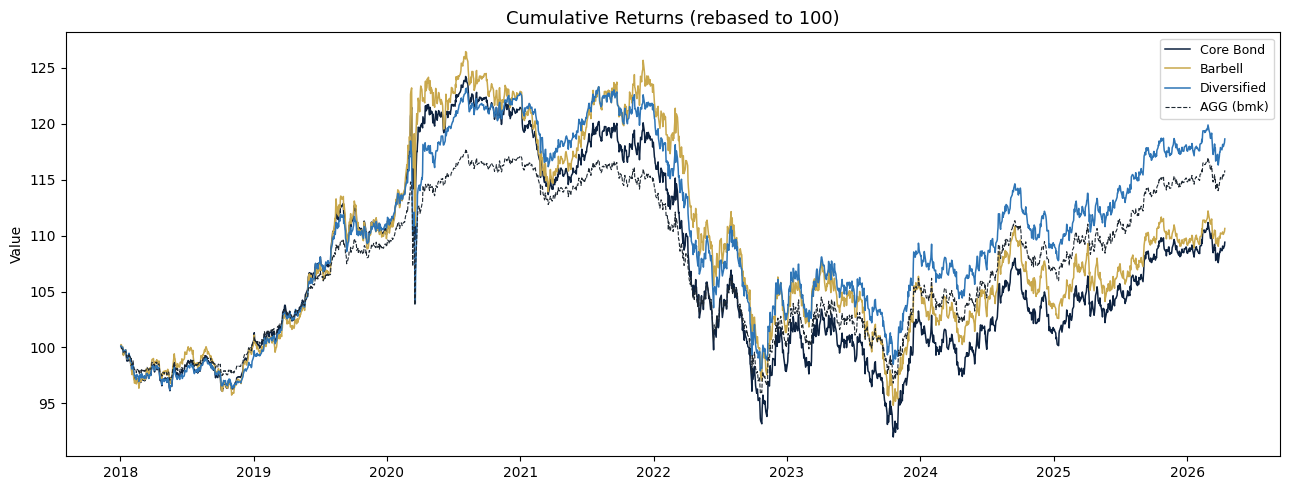

In [6]:
cum_series = {}
for p in all_ports:
    cum_series[p.name] = (1 + p.returns).cumprod() * 100

cum_df = pd.concat(cum_series, axis=1).dropna()
colors  = Palette.series(len(PORTFOLIOS))

fig, ax = plt.subplots(figsize=(13, 5))
for i, p in enumerate(PORTFOLIOS):
    ax.plot(cum_df.index, cum_df[p.name], color=colors[i], linewidth=1.1, label=p.name)
ax.plot(cum_df.index, cum_df[BENCHMARK.name],
        color=CHARCOAL, linewidth=0.8, linestyle="--", label=f"{BENCHMARK.name} (bmk)")
ax.set_title("Cumulative Returns (rebased to 100)", fontsize=13)
ax.set_ylabel("Value")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "output" / "port_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()

## Drawdowns

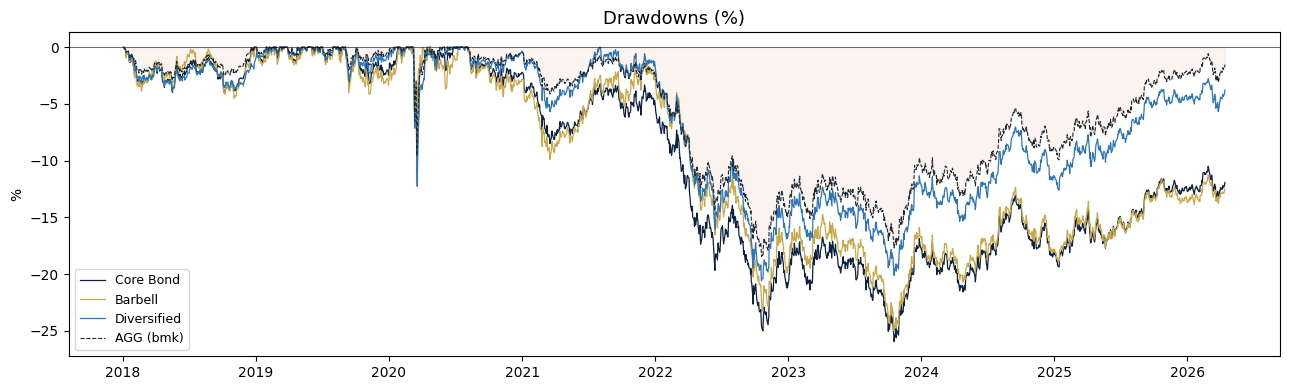

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
for i, p in enumerate(PORTFOLIOS):
    dd = p.drawdown() * 100
    ax.plot(dd.index, dd.values, color=colors[i], linewidth=0.9, label=p.name)
bm_dd = BENCHMARK.drawdown() * 100
ax.plot(bm_dd.index, bm_dd.values, color=CHARCOAL, linewidth=0.8,
        linestyle="--", label=f"{BENCHMARK.name} (bmk)")
ax.fill_between(bm_dd.index, bm_dd.values, 0, alpha=0.07, color=COPPER)
ax.axhline(0, color="black", linewidth=0.4)
ax.set_title("Drawdowns (%)", fontsize=13)
ax.set_ylabel("%")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "output" / "port_drawdowns.png", dpi=150, bbox_inches="tight")
plt.show()

## Rolling Sharpe & Volatility

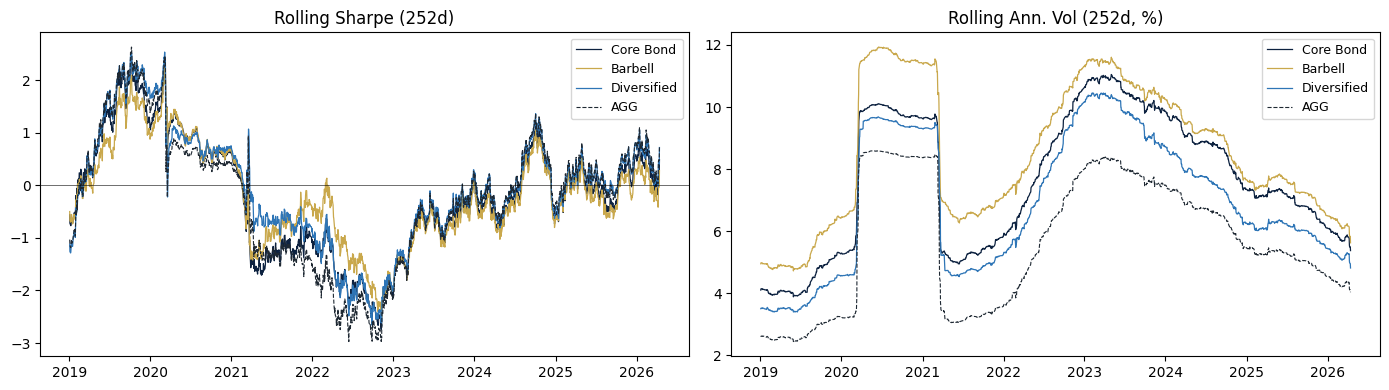

In [8]:
ROLL_WIN = 252

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, p in enumerate(PORTFOLIOS):
    rs = p.rolling_sharpe(window=ROLL_WIN, rf=RF).dropna()
    axes[0].plot(rs.index, rs.values, color=colors[i], linewidth=0.9, label=p.name)

bm_rs = BENCHMARK.rolling_sharpe(window=ROLL_WIN, rf=RF).dropna()
axes[0].plot(bm_rs.index, bm_rs.values, color=CHARCOAL, linewidth=0.8,
             linestyle="--", label=BENCHMARK.name)
axes[0].axhline(0, color="black", linewidth=0.4)
axes[0].set_title(f"Rolling Sharpe ({ROLL_WIN}d)", fontsize=12)
axes[0].legend(fontsize=9)

for i, p in enumerate(PORTFOLIOS):
    rv = p.rolling_vol(window=ROLL_WIN).dropna() * 100
    axes[1].plot(rv.index, rv.values, color=colors[i], linewidth=0.9, label=p.name)

bm_rv = BENCHMARK.rolling_vol(window=ROLL_WIN).dropna() * 100
axes[1].plot(bm_rv.index, bm_rv.values, color=CHARCOAL, linewidth=0.8,
             linestyle="--", label=BENCHMARK.name)
axes[1].set_title(f"Rolling Ann. Vol ({ROLL_WIN}d, %)", fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "output" / "port_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

## Calendar Year Returns

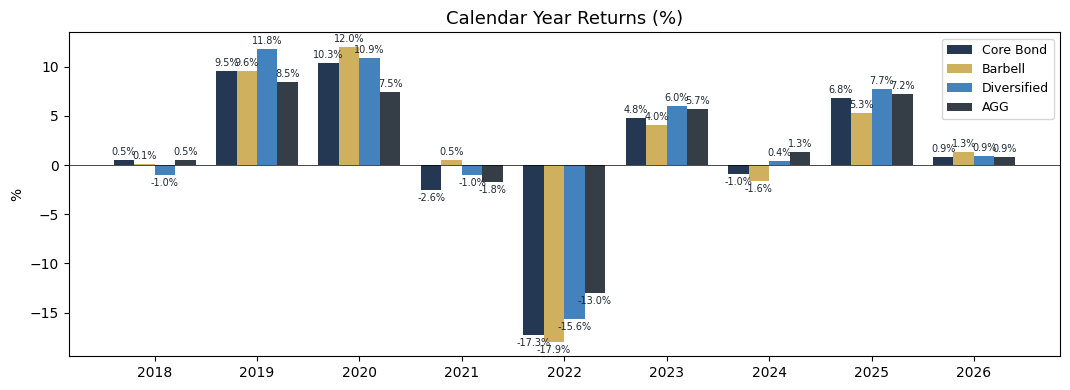

,Core Bond,Barbell,Diversified,AGG
Date,,,,
2018,0.49,0.15,-0.97,0.49
2019,9.55,9.56,11.76,8.46
2020,10.33,12.00,10.91,7.48
2021,-2.57,0.50,-0.96,-1.77
2022,-17.30,-17.94,-15.64,-13.02
2023,4.78,4.04,5.98,5.66
2024,-0.96,-1.65,0.43,1.31
2025,6.82,5.31,7.75,7.19
2026,0.86,1.30,0.88,0.87


In [9]:
def annual_returns(port: Portfolio) -> pd.Series:
    r = port.returns.dropna()
    return r.groupby(r.index.year).apply(lambda g: (1 + g).prod() - 1)

ann = pd.DataFrame({p.name: annual_returns(p) for p in all_ports})
ann_pct = ann * 100

fig, ax = plt.subplots(figsize=(max(10, len(ann) * 1.2), 4))
x   = np.arange(len(ann))
bar_w = 0.8 / len(all_ports)
for i, p in enumerate(all_ports):
    offset = (i - len(all_ports) / 2 + 0.5) * bar_w
    col = colors[i] if p != BENCHMARK else CHARCOAL
    bars = ax.bar(x + offset, ann_pct[p.name].values, width=bar_w,
                  color=col, label=p.name, alpha=0.9)
    for bar, val in zip(bars, ann_pct[p.name].values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3 * np.sign(val),
                f"{val:.1f}%", ha="center", va="bottom" if val >= 0 else "top",
                fontsize=7, color=CHARCOAL)

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(ann.index.astype(str))
ax.set_title("Calendar Year Returns (%)", fontsize=13)
ax.set_ylabel("%")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "output" / "port_calendar.png", dpi=150, bbox_inches="tight")
plt.show()

ann_pct.round(2)

## Monthly Returns Heatmap

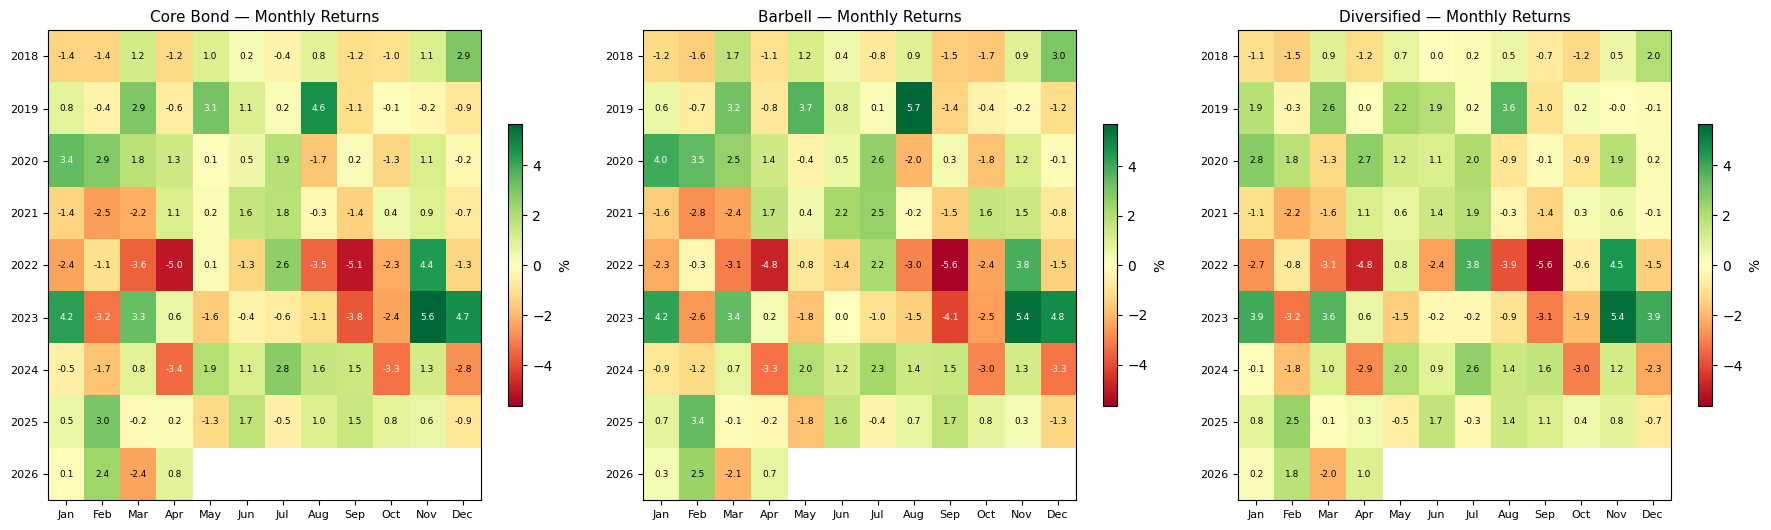

In [10]:
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

n_ports = len(PORTFOLIOS)
fig, axes = plt.subplots(1, n_ports, figsize=(6 * n_ports, max(4, 0.45 * 12)))
if n_ports == 1:
    axes = [axes]

for ax, p in zip(axes, PORTFOLIOS):
    r = p.returns.dropna()
    monthly = r.resample("ME").apply(lambda g: (1 + g).prod() - 1)
    pivot = monthly.groupby([monthly.index.year, monthly.index.month]).first().unstack() * 100
    pivot.columns = MONTHS[: pivot.shape[1]]

    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 0.01)
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    fig.colorbar(im, ax=ax, shrink=0.6, label="%")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.astype(str), fontsize=8)
    ax.set_title(f"{p.name} — Monthly Returns", fontsize=11)

    for yr in range(pivot.shape[0]):
        for mo in range(pivot.shape[1]):
            val = pivot.values[yr, mo]
            if not np.isnan(val):
                ax.text(mo, yr, f"{val:.1f}", ha="center", va="center",
                        fontsize=6.5, color="white" if abs(val) > vmax * 0.55 else "black")

plt.tight_layout()
plt.savefig(ROOT / "output" / "port_monthly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Portfolio Return Correlation

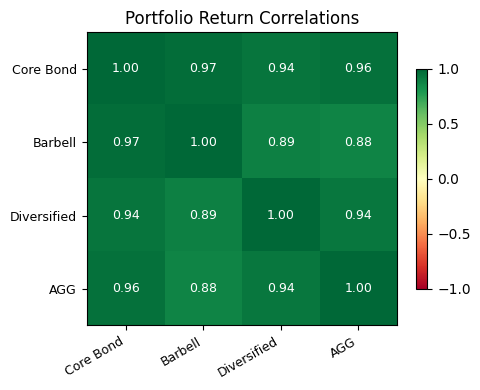

In [11]:
port_rets = pd.concat({p.name: p.returns for p in all_ports}, axis=1).dropna()
corr = port_rets.corr()

n = len(corr)
fig, ax = plt.subplots(figsize=(max(5, n * 1.1), max(4, n * 0.9)))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, shrink=0.75)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if abs(corr.values[i,j]) > 0.6 else "black")
ax.set_title("Portfolio Return Correlations", fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "output" / "port_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Risk Contribution by Holding

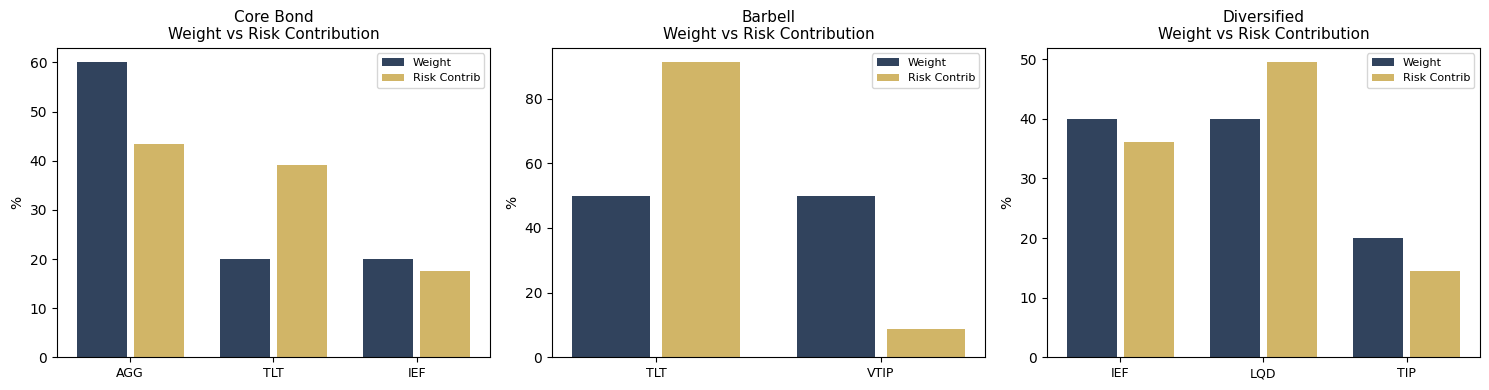

Core Bond              Barbell              Diversified             
        Weight Risk Contrib  Weight Risk Contrib      Weight Risk Contrib
AGG        0.6       0.4349     NaN          NaN         NaN          NaN
TLT        0.2       0.3905     0.5       0.9121         NaN          NaN
IEF        0.2       0.1746     NaN          NaN         0.4       0.3610
VTIP       NaN          NaN     0.5       0.0879         NaN          NaN
LQD        NaN          NaN     NaN          NaN         0.4       0.4945
TIP        NaN          NaN     NaN          NaN         0.2       0.1445

In [12]:
fig, axes = plt.subplots(1, len(PORTFOLIOS), figsize=(5 * len(PORTFOLIOS), 4))
if len(PORTFOLIOS) == 1:
    axes = [axes]

risk_frames = {}
for ax, p in zip(axes, PORTFOLIOS):
    rc   = p.risk_contribution()
    wts  = pd.Series(p.weights)
    risk_frames[p.name] = pd.DataFrame({"Weight": wts, "Risk Contrib": rc})

    syms   = rc.index.tolist()
    x      = np.arange(len(syms))
    pal    = Palette.navy(len(syms))

    b1 = ax.bar(x - 0.2, wts[syms].values * 100, width=0.35,
                color=NAVY, alpha=0.85, label="Weight")
    b2 = ax.bar(x + 0.2, rc[syms].values * 100, width=0.35,
                color=GOLD, alpha=0.85, label="Risk Contrib")

    ax.set_xticks(x)
    ax.set_xticklabels(syms, fontsize=9)
    ax.set_ylabel("%")
    ax.set_title(f"{p.name}\nWeight vs Risk Contribution", fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "output" / "port_risk_contrib.png", dpi=150, bbox_inches="tight")
plt.show()

# Table
all_risk = pd.concat(risk_frames, axis=1)
all_risk.round(4)

## Key Rate Duration Profile
Runs empirical OLS vs each tenor. Skip by setting `KRD_TENORS = []` in config.

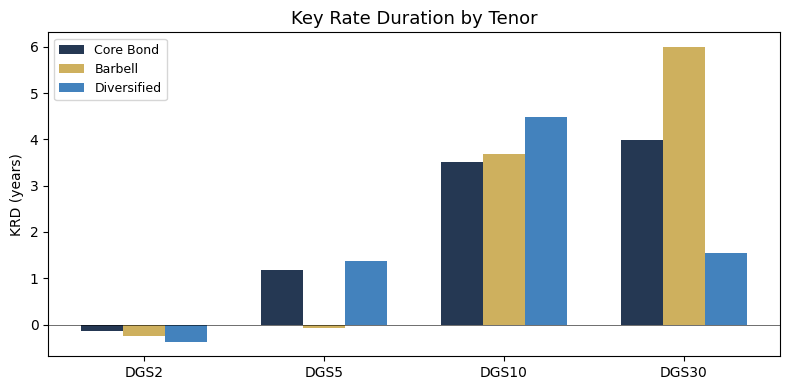


KRD Summary (portfolio-weighted, years):


,Core Bond,Barbell,Diversified
Tenor,,,
DGS2,-0.131,-0.239,-0.365
DGS5,1.189,-0.081,1.380
DGS10,3.511,3.679,4.477
DGS30,3.980,5.992,1.541


In [13]:
if KRD_TENORS:
    krd_frames = {}
    for p in PORTFOLIOS:
        krd = p.krd_profile(*KRD_TENORS)
        krd_frames[p.name] = krd["Portfolio"]  # portfolio-weighted column

    krd_summary = pd.DataFrame(krd_frames).loc[KRD_TENORS]  # tenor rows only

    # Grouped bar chart
    x     = np.arange(len(KRD_TENORS))
    bar_w = 0.7 / len(PORTFOLIOS)
    fig, ax = plt.subplots(figsize=(max(8, len(KRD_TENORS) * 1.5), 4))

    for i, p in enumerate(PORTFOLIOS):
        offset = (i - len(PORTFOLIOS) / 2 + 0.5) * bar_w
        ax.bar(x + offset, krd_summary[p.name].values,
               width=bar_w, color=colors[i], label=p.name, alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(KRD_TENORS, fontsize=10)
    ax.set_ylabel("KRD (years)")
    ax.set_title("Key Rate Duration by Tenor", fontsize=13)
    ax.axhline(0, color="black", linewidth=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(ROOT / "output" / "port_krd.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nKRD Summary (portfolio-weighted, years):")
    display(krd_summary.round(3))
else:
    print("KRD_TENORS is empty — skipping.")

## Active Return vs Benchmark

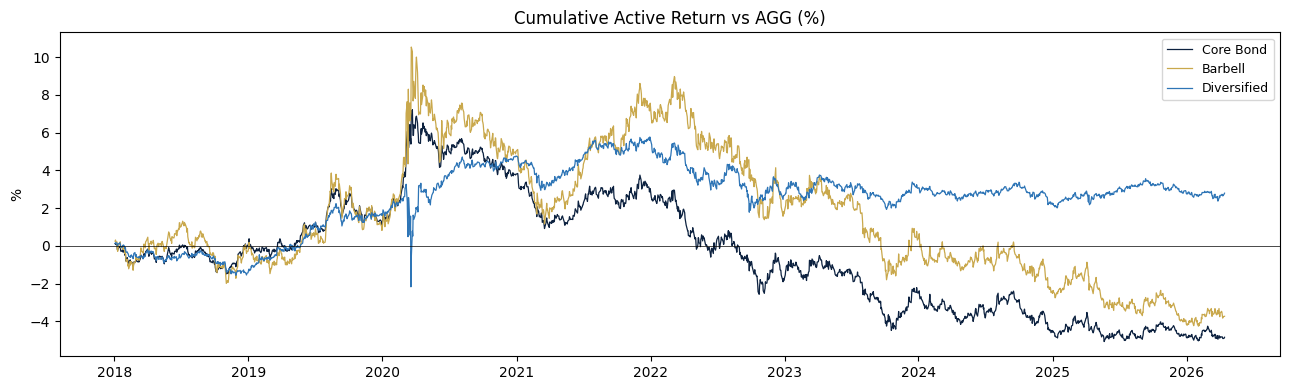

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
for i, p in enumerate(PORTFOLIOS):
    aligned = pd.concat([p.returns, BENCHMARK.returns], axis=1).dropna()
    active  = aligned.iloc[:, 0] - aligned.iloc[:, 1]
    cum_active = (1 + active).cumprod() - 1
    ax.plot(cum_active.index, cum_active.values * 100,
            color=colors[i], linewidth=0.9, label=p.name)

ax.axhline(0, color="black", linewidth=0.5)
ax.fill_between(cum_active.index, 0, 0, alpha=0)  # force legend
ax.set_title(f"Cumulative Active Return vs {BENCHMARK.name} (%)", fontsize=12)
ax.set_ylabel("%")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "output" / "port_active.png", dpi=150, bbox_inches="tight")
plt.show()

## Excel Export

In [15]:
wb = NotebookWorkbook(OUTPUT)

# Summary stats
wb.write("Stats", stats_df.reset_index().rename(columns={"index": "Metric"}))

# Calendar returns
wb.write("Calendar Returns", ann_pct.reset_index().rename(columns={"index": "Year"}))

# Correlation
wb.write("Correlation", corr.reset_index())

# Per-portfolio sheets
for p in PORTFOLIOS:
    p.to_excel(wb, prefix="")

# KRD summary
if KRD_TENORS:
    wb.write("KRD Profile", krd_summary.reset_index().rename(columns={"index": "Tenor"}))

# Cumulative returns
Panel(cum_df).to_excel(wb, "Cumulative Returns")

path = wb.save()
print(f"Saved → {path}")

Saved → C:\Users\btm74.000\Projects\qf_toolset\output\portfolio_comparison.xlsx
